In [1]:
import cx_Oracle
import itertools
import joblib
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
# import missingno as msno

In [2]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import  accuracy_score,roc_auc_score,average_precision_score,f1_score,precision_score,recall_score,classification_report,confusion_matrix
from xgboost import XGBClassifier
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from functools import  reduce
from sklearn.tree import DecisionTreeClassifier

In [3]:
%matplotlib inline
sns.set_style('whitegrid')
from matplotlib import font_manager
# font_path='/usr/share/fonts/cjkuni-uming/uming.ttc'
font_path = '/usr/share/fonts/truetype/arphic/uming.ttc'
matplotlib.rcParams['font.family']=font_manager.FontProperties(fname=font_path).get_name()
matplotlib.rcParams['axes.unicode_minus']=False

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
%matplotlib inline

### 读取高股息基金信息，筛选出持仓的高股息股票，只需要6月和12月持仓的高股息股票

In [6]:
# 获取高股息的基金代码，S_INFO_OUTERCODE：基金场外代码，F_INFO_FULLNAME：基金名称
connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
cursor = connection.cursor()
sql = "select S_INFO_OUTERCODE from ChinaMutualFundDescription where F_INFO_FULLNAME like '%股息%'"
print('从数据库中获取高股息基金数据: ' + sql)
cursor.execute(sql)
columns = [col[0] for col in cursor.description]
results = cursor.fetchall()
df1 = pd.DataFrame(results, columns=columns)
print(df1)
cursor.close()
connection.close()

从数据库中获取高股息基金数据: select S_INFO_OUTERCODE from ChinaMutualFundDescription where F_INFO_FULLNAME like '%股息%'
   S_INFO_OUTERCODE
0         005770.OF
1         004098.OF
2         004404.OF
3         015290.OF
4         022072.OF
..              ...
82        023105.OF
83        024247.OF
84        024140.OF
85        021049.OF
86        021050.OF

[87 rows x 1 columns]


In [7]:
# 获取高股息的基金的持股信息,F_PRT_ENDDATE:截止日期， S_INFO_STOCKWINDCODE：持有股票WIND代码，F_PRT_STKVALUETONAV：持有股票数量，F_PRT_STKVALUETONAV：持有股票市值占基金净值比例
def read_high_dividend(fund_name):
    connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
    cursor = connection.cursor()
    sql = "select F_PRT_ENDDATE, S_INFO_STOCKWINDCODE, F_PRT_STKVALUETONAV from ChinaMutualFundStockPortfolio where S_INFO_OUTERCODE = '" + fund_name + "'and REPORT_TYPE = '中/年报' order by F_PRT_ENDDATE desc"
    print('从数据库中获取基金持股数据: ' + sql)
    cursor.execute(sql)
    columns = [col[0] for col in cursor.description]
    results = cursor.fetchall()
    df = pd.DataFrame(results, columns=columns)
    # print(df)
    cursor.close()
    connection.close()
    return df


In [8]:
fund_df=df1
High_dividend=[]
for fund in fund_df['S_INFO_OUTERCODE']:
    df_stock_info=read_high_dividend(fund)
    df_stock_info = df_stock_info[~df_stock_info['S_INFO_STOCKWINDCODE'].str.endswith('.HK',na=False)]
    if df_stock_info is not None:
        df_stock_info['Fund_Name']=fund
        High_dividend.append(df_stock_info)

从数据库中获取基金持股数据: select F_PRT_ENDDATE, S_INFO_STOCKWINDCODE, F_PRT_STKVALUETONAV from ChinaMutualFundStockPortfolio where S_INFO_OUTERCODE = '005770.OF'and REPORT_TYPE = '中/年报' order by F_PRT_ENDDATE desc
从数据库中获取基金持股数据: select F_PRT_ENDDATE, S_INFO_STOCKWINDCODE, F_PRT_STKVALUETONAV from ChinaMutualFundStockPortfolio where S_INFO_OUTERCODE = '004098.OF'and REPORT_TYPE = '中/年报' order by F_PRT_ENDDATE desc
从数据库中获取基金持股数据: select F_PRT_ENDDATE, S_INFO_STOCKWINDCODE, F_PRT_STKVALUETONAV from ChinaMutualFundStockPortfolio where S_INFO_OUTERCODE = '004404.OF'and REPORT_TYPE = '中/年报' order by F_PRT_ENDDATE desc
从数据库中获取基金持股数据: select F_PRT_ENDDATE, S_INFO_STOCKWINDCODE, F_PRT_STKVALUETONAV from ChinaMutualFundStockPortfolio where S_INFO_OUTERCODE = '015290.OF'and REPORT_TYPE = '中/年报' order by F_PRT_ENDDATE desc
从数据库中获取基金持股数据: select F_PRT_ENDDATE, S_INFO_STOCKWINDCODE, F_PRT_STKVALUETONAV from ChinaMutualFundStockPortfolio where S_INFO_OUTERCODE = '022072.OF'and REPORT_TYPE = '中/年报' order by F_PR

In [9]:
no_empyt_df=[df for df in High_dividend if not df.empty]
# High_dividend_df=pd.concat(no_empyt_df,ignore_index=True)

In [10]:
len(no_empyt_df)

30

In [11]:
High_dividend_df=no_empyt_df

In [12]:
High_dividend_df[5]['Fund_Name'][0]

'004403.OF'

In [13]:
High_dividend_df

[    F_PRT_ENDDATE S_INFO_STOCKWINDCODE  F_PRT_STKVALUETONAV  Fund_Name
 2        20221231            600586.SH                 0.16  005770.OF
 3        20221231            600563.SH                 0.13  005770.OF
 4        20221231            600273.SH                 0.40  005770.OF
 5        20221231            600993.SH                 0.14  005770.OF
 6        20221231            002001.SZ                 0.21  005770.OF
 ..            ...                  ...                  ...        ...
 658      20190630            600054.SH                 0.44  005770.OF
 659      20190630            600201.SH                 0.43  005770.OF
 660      20190630            603027.SH                 0.42  005770.OF
 661      20190630            300394.SZ                 0.41  005770.OF
 662      20190630            002626.SZ                 0.41  005770.OF
 
 [570 rows x 4 columns],
     F_PRT_ENDDATE S_INFO_STOCKWINDCODE  F_PRT_STKVALUETONAV  Fund_Name
 5        20241231            600567.

In [14]:
#筛选数据量大于50的基金
# High_dividend_df1=[]
# for df in High_dividend_df:
#     if len(df)>50:
#         High_dividend_df1.append(df)

In [15]:
# len(High_dividend_df1)

In [16]:
# 创建一个字典来存储每个日期对应的股票列表
from collections import defaultdict
date_to_stocks = defaultdict(list)

# 合并所有DataFrame并按照日期分组
for df in High_dividend_df:
    # 确保日期列是字符串格式
    df['F_PRT_ENDDATE'] = df['F_PRT_ENDDATE'].astype(str)
    # 按日期分组并收集股票代码
    for date, group in df.groupby('F_PRT_ENDDATE'):
        stocks = group['S_INFO_STOCKWINDCODE'].unique().tolist()
        date_to_stocks[date].extend(stocks)

# 去重每个日期下的股票代码
for date in date_to_stocks:
    date_to_stocks[date] = list(set(date_to_stocks[date]))

# 转换为一个DataFrame，每行显示一个日期和对应的股票列表
result_df = pd.DataFrame({
    'Date': date_to_stocks.keys(),
    'Stock_List': date_to_stocks.values()
})

In [17]:
result_df

,Date,Stock_List
0,20190630,"[002237.SZ, 603589.SH, 600012.SH, 600409.SH, 0..."
1,20191231,"[601318.SH, 002587.SZ, 603589.SH, 600406.SH, 0..."
2,20200630,"[600886.SH, 601117.SH, 600019.SH, 000988.SZ, 0..."
3,20201231,"[603515.SH, 002880.SZ, 002557.SZ, 300890.SZ, 6..."
4,20210630,"[603515.SH, 002880.SZ, 002557.SZ, 001208.SZ, 3..."
5,20211231,"[002557.SZ, 001208.SZ, 600406.SH, 301118.SZ, 3..."
6,20220630,"[603290.SH, 301148.SZ, 002557.SZ, 001208.SZ, 6..."
7,20221231,"[600406.SH, 300068.SZ, 301298.SZ, 600019.SH, 0..."
8,20231231,"[002004.SZ, 002034.SZ, 603515.SH, 301148.SZ, 0..."
9,20240630,"[002004.SZ, 002034.SZ, 603515.SH, 002557.SZ, 3..."


In [18]:
dates_to_remove = ['20250401', '20240507','20200506','20190301']  # 要删除的日期列表
result_df = result_df[~result_df['Date'].isin(dates_to_remove)]
result_df 

,Date,Stock_List
0,20190630,"[002237.SZ, 603589.SH, 600012.SH, 600409.SH, 0..."
1,20191231,"[601318.SH, 002587.SZ, 603589.SH, 600406.SH, 0..."
2,20200630,"[600886.SH, 601117.SH, 600019.SH, 000988.SZ, 0..."
3,20201231,"[603515.SH, 002880.SZ, 002557.SZ, 300890.SZ, 6..."
4,20210630,"[603515.SH, 002880.SZ, 002557.SZ, 001208.SZ, 3..."
5,20211231,"[002557.SZ, 001208.SZ, 600406.SH, 301118.SZ, 3..."
6,20220630,"[603290.SH, 301148.SZ, 002557.SZ, 001208.SZ, 6..."
7,20221231,"[600406.SH, 300068.SZ, 301298.SZ, 600019.SH, 0..."
8,20231231,"[002004.SZ, 002034.SZ, 603515.SH, 301148.SZ, 0..."
9,20240630,"[002004.SZ, 002034.SZ, 603515.SH, 002557.SZ, 3..."


#### 每个日期对应的基金持仓的高股息股票dataframe

In [19]:
result_df =result_df.sort_values(by='Date')
result_df

,Date,Stock_List
20,20150630,"[002001.SZ, 600694.SH, 601006.SH, 600269.SH, 6..."
21,20151231,"[600863.SH, 002557.SZ, 600027.SH, 600658.SH, 6..."
22,20160630,"[002004.SZ, 600266.SH, 600027.SH, 603737.SH, 0..."
23,20161231,"[002004.SZ, 600266.SH, 603298.SH, 600027.SH, 0..."
19,20170630,"[600271.SH, 600012.SH, 600027.SH, 000625.SZ, 0..."
11,20171231,"[600271.SH, 600132.SH, 600012.SH, 600027.SH, 0..."
12,20180630,"[600271.SH, 600027.SH, 600409.SH, 000625.SZ, 6..."
13,20181231,"[600132.SH, 601318.SH, 603589.SH, 600409.SH, 0..."
0,20190630,"[002237.SZ, 603589.SH, 600012.SH, 600409.SH, 0..."
1,20191231,"[601318.SH, 002587.SZ, 603589.SH, 600406.SH, 0..."


In [20]:
# 158用单独的时间列表读取，是因为在某些日期158没有值，所以往前提前1-3天
dates_158=['20150630','20151231','20160630','20161230','20170630','20171229','20180628','20181228','20190628','20191231',
           '20200630','20201231','20210630','20211231','20220630','20221229','20230630','20231229','20240628','20241231']
dates_158

['20150630',
 '20151231',
 '20160630',
 '20161230',
 '20170630',
 '20171229',
 '20180628',
 '20181228',
 '20190628',
 '20191231',
 '20200630',
 '20201231',
 '20210630',
 '20211231',
 '20220630',
 '20221229',
 '20230630',
 '20231229',
 '20240628',
 '20241231']

### 读取财务和量价158数据，时间截面对应即可，并合并数据构造特征和标签，最后返回一个list，里面有对应每个日期的包含特征和标签的结果dataframe

In [21]:
final_df=[]
for date,date1 in zip(result_df['Date'],dates_158):
    start_date=date
    start_date1=date1
    stock_list=result_df.loc[result_df['Date'] == start_date, 'Stock_List'].values[0]
    # start_date1=
    connection = cx_Oracle.connect('jylh', 'jylh', '10.6.60.114:1521/wind')
    cursor = connection.cursor()
    sql = "select * from JY_QY_QLIB_ALPHA158 where DATETIME= :date_param"
    cursor.execute(sql, (start_date1,))
    columns = [col[0] for col in cursor.description]
    results = cursor.fetchall()
    X_df1 = pd.DataFrame(results, columns=columns)
    
    connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
    cursor = connection.cursor()
    sql = "select * FROM ASHAREBALANCESHEETHIS where REPORT_PERIOD= :date_param and STATEMENT_TYPE IN (408001000,408005000,408027000,408028000,408003600,408045000)"
    cursor.execute(sql, (start_date,))
    columns = [col[0] for col in cursor.description]
    results = cursor.fetchall()
    X_df2 = pd.DataFrame(results, columns=columns)
    
    connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
    cursor = connection.cursor()
    sql = "select * FROM ASHAREINCOMEHIS where REPORT_PERIOD= :date_param and STATEMENT_TYPE IN (408001000,408005000,408027000,408028000,408003600,408045000)"
    cursor.execute(sql, (start_date,))
    columns = [col[0] for col in cursor.description]
    results = cursor.fetchall()
    X_df3 = pd.DataFrame(results, columns=columns)
    
    connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
    cursor = connection.cursor()
    sql = "select * FROM ASHARECASHFLOWHIS where REPORT_PERIOD= :date_param and STATEMENT_TYPE IN (408001000,408005000,408027000,408028000,408003600,408045000)"
    cursor.execute(sql, (start_date,))
    columns = [col[0] for col in cursor.description]
    results = cursor.fetchall()
    X_df4 = pd.DataFrame(results, columns=columns)
    
    connection = cx_Oracle.connect('wind', 'wind', '10.6.60.114:1521/wind')
    cursor = connection.cursor()
    sql = "select * FROM ASHAREFINANCIALINDICATOR where REPORT_PERIOD= :date_param"
    cursor.execute(sql, (start_date,))
    columns = [col[0] for col in cursor.description]
    results = cursor.fetchall()
    X_df5 = pd.DataFrame(results, columns=columns)
    
    #合并前删掉一些不必要的列
    X_df2.drop(['OBJECT_ID','S_INFO_COMPCODE','ANN_DT','ACTUAL_ANN_DT','REPORT_PERIOD','STATEMENT_TYPE_WIND','STATEMENT_TYPE','CRNCY_CODE','OPDATE','OPMODE'],axis=1,inplace=True)
    X_df3.drop(['OBJECT_ID','S_INFO_COMPCODE','ANN_DT','ACTUAL_ANN_DT','REPORT_PERIOD','STATEMENT_TYPE_WIND','STATEMENT_TYPE','CRNCY_CODE','OPDATE','OPMODE'],axis=1,inplace=True)
    X_df4.drop(['OBJECT_ID','S_INFO_COMPCODE','ANN_DT','ACTUAL_ANN_DT','REPORT_PERIOD','STATEMENT_TYPE_WIND','STATEMENT_TYPE','CRNCY_CODE','OPDATE','OPMODE'],axis=1,inplace=True)
    X_df5.drop(['OBJECT_ID','WIND_CODE','S_INFO_COMPCODE','ANN_DT','REPORT_PERIOD','STATEMENT_TYPE','CRNCY_CODE','OPDATE','OPMODE'],axis=1,inplace=True)
    
    print(X_df1.shape)
    print(X_df2.shape)
    print(X_df3.shape)
    print(X_df4.shape)
    print(X_df5.shape)
    
    # 合并数据，构建X
    merged_df = pd.merge(X_df1, X_df2, left_on=['CODE'], right_on=['S_INFO_WINDCODE'],
                                  how='left')
    merged_df1 = pd.merge(merged_df, X_df3, on=['S_INFO_WINDCODE'], how='left')
    merged_df2 = pd.merge(merged_df1, X_df4, on=['S_INFO_WINDCODE'], how='left')
    merged_df3 = pd.merge(merged_df2, X_df5, on=['S_INFO_WINDCODE'], how='left')
    merged_df3.drop(['S_INFO_WINDCODE'],axis=1,inplace=True)
    
    #构造标签列
    merged_df3['label']=merged_df3['CODE'].isin(stock_list).astype(int)
    
    object_columns = merged_df3.select_dtypes(include=['object']).columns.tolist()
    #删除数据类型为object的列
    merged_df3.drop(object_columns[2:],axis=1,inplace=True)
    merged_df4=merged_df3
    print(merged_df4.columns[:5])
    final_df.append(merged_df4)


(2812, 161)
(2829, 172)
(2911, 94)
(2904, 112)
(4174, 164)
Index(['DATETIME', 'CODE', 'KMID', 'KLEN', 'KMID2'], dtype='object')
(2881, 161)
(2994, 172)
(2990, 94)
(2919, 112)
(5661, 164)
Index(['DATETIME', 'CODE', 'KMID', 'KLEN', 'KMID2'], dtype='object')
(2000, 161)
(2969, 172)
(3143, 94)
(3132, 112)
(4864, 164)
Index(['DATETIME', 'CODE', 'KMID', 'KLEN', 'KMID2'], dtype='object')
(3160, 161)
(3332, 172)
(3308, 94)
(3245, 112)
(5817, 164)
Index(['DATETIME', 'CODE', 'KMID', 'KLEN', 'KMID2'], dtype='object')
(3339, 161)
(3401, 172)
(3437, 94)
(3422, 112)
(5047, 164)
Index(['DATETIME', 'CODE', 'KMID', 'KLEN', 'KMID2'], dtype='object')
(3630, 161)
(3758, 172)
(3752, 94)
(3666, 112)
(6136, 164)
Index(['DATETIME', 'CODE', 'KMID', 'KLEN', 'KMID2'], dtype='object')
(2879, 161)
(3642, 172)
(3711, 94)
(3682, 112)
(4923, 164)
Index(['DATETIME', 'CODE', 'KMID', 'KLEN', 'KMID2'], dtype='object')
(3749, 161)
(3888, 172)
(3878, 94)
(3789, 112)
(6548, 164)
Index(['DATETIME', 'CODE', 'KMID', 'KLEN', 'K

### 针对得到的final_df结果,纵向拼接所有日期的结果，得到combined_df

In [22]:
#1. 找出共同列
common_columns = set(final_df[0].columns)
for df in final_df[1:]:
    common_columns.intersection_update(df.columns)
common_columns = list(common_columns)

print(f"找到 {len(common_columns)} 个共同列")

# 2. 筛选共同列
filtered_dfs = [df[common_columns] for df in final_df]

# 3. 拼接DataFrame
combined_df = pd.concat(filtered_dfs, axis=0, ignore_index=True)

print("拼接结果:")
print(combined_df.shape)
print(combined_df.head())

找到 583 个共同列
拼接结果:
(94885, 583)
     CNTN60  IMXD5      TOT_LIAB  S_QFA_SALESCASHINTOOR    SUMN10  RANK5  \
0  0.483333   -0.4  2.419628e+12                    NaN  0.653341    0.6   
1  0.483333   -0.2  4.191378e+11               105.9044  0.546040    1.0   
2  0.383333   -0.4  1.868651e+08                84.8346  0.665282    0.6   
3  0.216667   -0.6  6.950709e+08                57.6842  0.891742    0.4   
4  0.400000   -0.6  7.445918e+09               107.2902  0.765714    0.6   

   CNTD5  S_FA_EPS_BASIC_y  REINSURANCE_EXP    STM_BS_TOT  ...    QTLU60  \
0   -0.2            0.8400              NaN           NaN  ...  1.141955   
1    0.2            0.4390              NaN  3.767589e+09  ...  1.025759   
2    0.2            0.0144              NaN  3.879128e+07  ...  1.028979   
3    0.2           -0.0250              NaN  2.536110e+07  ...  1.468336   
4   -0.2            0.1912              NaN  3.682630e+06  ...  1.223865   

   S_QFA_ROA  PROC_ISSUE_BONDS  S_FA_INVESTINCOME      

#### 构造X--特征集，y---标签集

In [23]:
#特征与标签,排除非特征列
X=combined_df.drop(columns=['CODE','label','DATETIME'])

In [24]:
X.head()

,CNTN60,IMXD5,TOT_LIAB,S_QFA_SALESCASHINTOOR,SUMN10,RANK5,CNTD5,S_FA_EPS_BASIC_y,REINSURANCE_EXP,STM_BS_TOT,...,QTLU60,S_QFA_ROA,PROC_ISSUE_BONDS,S_FA_INVESTINCOME,INC_TAX,QTLU5,LOSS_SCR_FA,RED_MONETARY_CAP_FOR_SALE,LESS_IMPAIR_LOSS_ASSETS,HIGH0
0,0.483333,-0.4,2.419628e+12,NaN,0.653341,0.6,-0.2,0.8400,NaN,NaN,...,1.141955,0.2443,1.234790e+11,1.674000e+09,3.674000e+09,1.026137,NaN,3.068690e+11,1.292300e+10,1.000000
1,0.483333,-0.2,4.191378e+11,105.9044,0.546040,1.0,0.2,0.4390,NaN,3.767589e+09,...,1.025759,1.1066,NaN,9.156905e+08,1.987526e+09,0.992287,NaN,NaN,2.435777e+07,1.006887
2,0.383333,-0.4,1.868651e+08,84.8346,0.665282,0.6,0.2,0.0144,NaN,3.879128e+07,...,1.028979,1.7845,NaN,-1.278559e+05,2.154554e+06,1.012195,NaN,NaN,NaN,1.042055
3,0.216667,-0.6,6.950709e+08,57.6842,0.891742,0.4,0.2,-0.0250,NaN,2.536110e+07,...,1.468336,-1.1198,NaN,NaN,NaN,1.203408,NaN,NaN,NaN,1.014104
4,0.400000,-0.6,7.445918e+09,107.2902,0.765714,0.6,-0.2,0.1912,NaN,3.682630e+06,...,1.223865,0.4834,NaN,-1.710140e+05,9.208078e+07,1.114067,NaN,NaN,2.133873e+06,1.001474


In [25]:
print(X.shape)

(94885, 580)


In [26]:
y=combined_df['label']

In [27]:
y.shape

(94885,)

In [28]:
#有些情况需要，例如找到预测标签为1对应的股票
y_code=combined_df[['CODE','DATETIME','label']]

In [29]:
y_code.head()

,CODE,DATETIME,label
0,000001.SZ,20150630,0
1,000002.SZ,20150630,0
2,000004.SZ,20150630,0
3,000005.SZ,20150630,0
4,000006.SZ,20150630,0


In [30]:
#模型评估指标函数，打印Recall和F1
def metric_score(test_y,pre_y):
    #模型评估
    accuracy=accuracy_score(test_y,pre_y)
    auroc=roc_auc_score(test_y,pre_y)
    aupr=average_precision_score(test_y,pre_y)
    f1=f1_score(test_y,pre_y)
    precision=precision_score(test_y,pre_y)
    recall=recall_score(test_y,pre_y)
    
    #分类报告
    report=classification_report(test_y,pre_y)
    
    # print(report)
    print("Recall:%.3f"% recall)
    print("Precision:%.3f"% precision)
    print("F1:%.3f"% f1)

In [31]:
def plot_confusion_matrix(cm,classes,fund_name,cmap=plt.cm.Blues):
    plt.imshow(cm,interpolation='nearest',cmap=cmap)
    plt.title(f'{fund_name}_confusion_matrix')
    plt.colorbar()
    tick_marks=np.arange(len(classes))
    plt.xticks(tick_marks,classes)
    plt.yticks(tick_marks,classes)
    
    thresh=cm.max()/2
    for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,cm[i,j],horizontalalignment='center',color='white' if cm[i,j]>thresh else 'black')
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predict label')
    plt.savefig(f'data/fund/fig/{fund_name}_confusion_matrix.svg')

In [32]:
#训练集测试集划分，训练集放入全部正样本，负样本进行欠采样，预测时放入全部样本
#保留正样本，欠采样负样本
rus=RandomUnderSampler(sampling_strategy=0.5) #比例1：10
X_train_rus,y_train_rus=rus.fit_resample(X,y)
X_test,y_test=X,y

In [33]:
#统计当前类别占比情况
print("Before undersampling:",Counter(y))

Before undersampling: Counter({0: 87440, 1: 7445})


In [34]:
#欠采样后类别占比情况
print("After undersampling:",Counter(y_train_rus))

After undersampling: Counter({0: 14890, 1: 7445})


In [35]:
#XGBoost模型定义与训练
xgb_model=XGBClassifier()
xgb_model.fit(X_train_rus,y_train_rus)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [36]:
#XGBoost模型评估,Recall:实际为正类样本中被正确预测为正类的比例，Precision：预测为正类的样本中实际为正类的比例，F1：2×（（recall×precision）/（recall+precision））
y_pred=xgb_model.predict(X_test)
metric_score(test_y=y_test,pre_y=y_pred)

Recall:0.992
Precision:0.487
F1:0.653


In [37]:
#模型的预测结果整合，便于后续分析
y_pred_df=pd.DataFrame(y_pred,columns=['pred_label'])
positive_df = y_code.join(y_pred_df)
positive_df.head()

,CODE,DATETIME,label,pred_label
0,000001.SZ,20150630,0,1
1,000002.SZ,20150630,0,1
2,000004.SZ,20150630,0,0
3,000005.SZ,20150630,0,0
4,000006.SZ,20150630,0,0


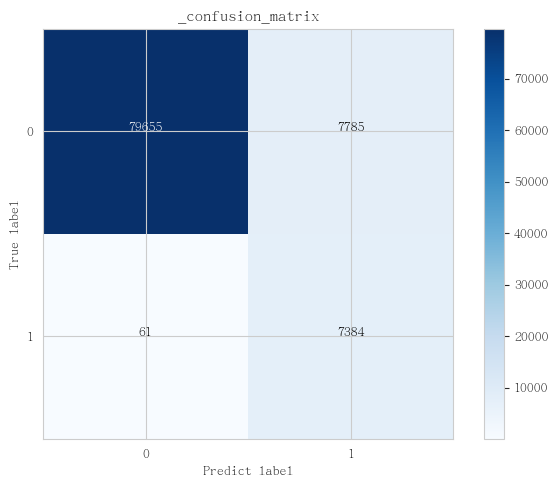

In [38]:
#默认阈值一般为0.5
y_pred_recall=y_pred[0:]>0.5
cnf_matrix=confusion_matrix(y_test,y_pred_recall)
class_names=[0,1]
plot_confusion_matrix(cnf_matrix,classes=class_names,fund_name='')

In [39]:
explainer=shap.Explainer(xgb_model)
shape_value=explainer.shap_values(X)
shap_df=pd.DataFrame(shape_value,columns=X_train_rus.columns)

In [40]:
# #输出每个特征的SHAP值（绝对值）
features=[]
shap_values_means=[]
for i,feature in enumerate(X_train_rus.columns):
    shap_values_mean=np.abs(shap_df.values[:,i]).mean()
    features.append(feature)
    shap_values_means.append(shap_values_mean)
tt=pd.DataFrame(features,columns=['features'])
tt['shap_values']=shap_values_means
tt_sort=tt.sort_values(by='shap_values',ascending=False)

In [41]:
tt_sort

,features,shap_values
416,S_FA_DEDUCTEDPROFIT,0.408271
556,CASH_PAY_DIST_DPCP_INT_EXP,0.274871
405,S_FA_SURPLUSRESERVEPS,0.205099
170,ADV_FROM_CUST,0.198644
344,VWAP0,0.186635
...,...,...
127,TIME_DEPOSITS,0.000000
125,SPE_BAL_ASSETS_DIFF,0.000000
491,CASH_PAY_CLAIMS_ORIG_INCO,0.000000
124,S_FA_DEBTTOEQUITY,0.000000


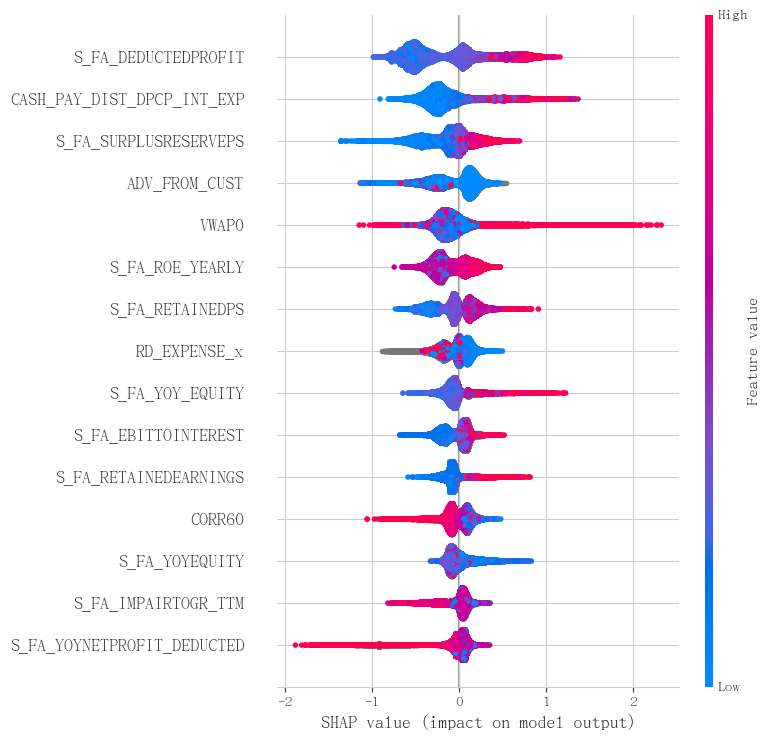

In [42]:
#摘要图，横轴：shap值，正的（正面影响）；纵轴：特征对模型预测贡献的平均绝对值排序；每个点代表一个样本，点的颜色表示该特征的值（红色表示特征值较高，蓝色表示特征值较低）
#正SHAP值表示该特征提高了对预测结果倾向于1的贡献
shape_value=explainer.shap_values(X)
shap.summary_plot(shape_value,X,max_display=15)

### 进一步分类，根据半年后股票收益率，判断高股息股票中的好与坏

In [43]:
#处理完成后的每个时间对应的基金持仓的高股息股票dataframe
result_df=result_df.reset_index(drop=True)
result_df

,Date,Stock_List
0,20150630,"[002001.SZ, 600694.SH, 601006.SH, 600269.SH, 6..."
1,20151231,"[600863.SH, 002557.SZ, 600027.SH, 600658.SH, 6..."
2,20160630,"[002004.SZ, 600266.SH, 600027.SH, 603737.SH, 0..."
3,20161231,"[002004.SZ, 600266.SH, 603298.SH, 600027.SH, 0..."
4,20170630,"[600271.SH, 600012.SH, 600027.SH, 000625.SZ, 0..."
5,20171231,"[600271.SH, 600132.SH, 600012.SH, 600027.SH, 0..."
6,20180630,"[600271.SH, 600027.SH, 600409.SH, 000625.SZ, 6..."
7,20181231,"[600132.SH, 601318.SH, 603589.SH, 600409.SH, 0..."
8,20190630,"[002237.SZ, 603589.SH, 600012.SH, 600409.SH, 0..."
9,20191231,"[601318.SH, 002587.SZ, 603589.SH, 600406.SH, 0..."


#### 计算半年后股票的收益率

In [44]:
dates_close=['20150630','20151231','20160630','20161230','20170630','20171229','20180628','20181228','20190628','20191231','20200630',
           '20201231','20210630','20211231','20220630','20221229','20230630','20231229','20240628','20241231']
#六个月后股票的日期列表
dates_close_6=['20151230','20160630','20161230','20170630','20171229','20180629','20181228','20190628','20191227','20200630','20201230',
           '20210630','20211230','20220630','20221230','20230629','20231229','20240628','20241227','20250512']
#当前与六个月后的股票行情数据
data_close=[]
data_close_6=[]
for date in dates_close:
    connection = cx_Oracle.connect('jylh', 'jylh', '10.6.60.114:1521/wind')
    cursor = connection.cursor()
    sql = "select * from JY_QY_STOCKQUOTATION_CS where TRADEDATE= :date_param"
    cursor.execute(sql, (date,))
    columns = [col[0] for col in cursor.description]
    results = cursor.fetchall()
    close_df = pd.DataFrame(results, columns=columns)
    close_df=close_df[['TRADEDATE','STOCKCODE','CLOSE']]
    data_close.append(close_df)
    print(close_df.shape)
for date in dates_close_6:
    connection = cx_Oracle.connect('jylh', 'jylh', '10.6.60.114:1521/wind')
    cursor = connection.cursor()
    sql = "select * from JY_QY_STOCKQUOTATION_CS where TRADEDATE= :date_param"
    cursor.execute(sql, (date,))
    columns = [col[0] for col in cursor.description]
    results = cursor.fetchall()
    close_df_6 = pd.DataFrame(results, columns=columns)
    close_df_6=close_df_6[['TRADEDATE','STOCKCODE','CLOSE']]
    data_close_6.append(close_df_6)
    print(close_df_6.shape)
    

(2808, 3)
(2879, 3)
(2965, 3)
(3155, 3)
(3420, 3)
(3625, 3)
(3699, 3)
(3746, 3)
(3810, 3)
(3940, 3)
(4073, 3)
(4345, 3)
(4597, 3)
(4832, 3)
(4956, 3)
(5140, 3)
(5259, 3)
(5343, 3)
(5363, 3)
(5383, 3)
(2871, 3)
(2965, 3)
(3155, 3)
(3420, 3)
(3625, 3)
(3699, 3)
(3746, 3)
(3810, 3)
(3937, 3)
(4073, 3)
(4342, 3)
(4597, 3)
(4831, 3)
(4956, 3)
(5143, 3)
(5258, 3)
(5343, 3)
(5363, 3)
(5382, 3)
(5411, 3)


In [45]:
returns_list = []  # 用于存储每个日期的收益率DataFrame
i=0
for current_df, past_df in zip(data_close_6, data_close):
    # 合并当前和前六个月的数据，基于STOCKCODE
    merged = pd.merge(current_df, past_df, on='STOCKCODE', suffixes=('_current', '_past'))
    
    # 计算收益率: (当前收盘价 - 前六个月收盘价) / 前六个月收盘价
    merged['RETURN'] = (merged['CLOSE_current'] - merged['CLOSE_past']) / merged['CLOSE_past']
    
    # 选择需要的列
    result = merged[['TRADEDATE_past', 'STOCKCODE', 'RETURN']]
    result = result.rename(columns={'TRADEDATE_current': 'TRADEDATE'})
    
    result=result[result['STOCKCODE'].isin(result_df['Stock_List'][i])]
    i+=1
    returns_list.append(result)

In [46]:
returns_list

[     TRADEDATE_past  STOCKCODE    RETURN
 8          20150630  601088.SH -0.277572
 15         20150630  601877.SH -0.144541
 29         20150630  000778.SZ -0.491494
 31         20150630  000858.SZ -0.130595
 264        20150630  600309.SH -0.264279
 ...             ...        ...       ...
 2683       20150630  000402.SZ -0.140845
 2745       20150630  002771.SZ  5.188241
 2768       20150630  600019.SH -0.360819
 2774       20150630  600123.SH -0.317967
 2796       20150630  601369.SH -0.241912
 
 [67 rows x 3 columns],
      TRADEDATE_past  STOCKCODE    RETURN
 14         20151231  000828.SZ -0.261512
 30         20151231  002372.SZ  0.076449
 64         20151231  600177.SH -0.106428
 85         20151231  600886.SH -0.209587
 110        20151231  000402.SZ -0.156982
 ...             ...        ...       ...
 2631       20151231  002039.SZ -0.002268
 2646       20151231  002311.SZ  0.145160
 2678       20151231  000690.SZ -0.286698
 2732       20151231  600183.SH -0.032650
 2804   

### 计算中证800收益率----现在是中证500红利全收益指数

In [47]:
connection = cx_Oracle.connect('jylh', 'jylh', '10.6.60.114:1521/wind')
cursor = connection.cursor()
sql = "select TRADEDATE,TCLOSE from JY_QY_INDEXDATA_CS where INDEXCODE='2070003752' and TRADEDATE>='20150630' order by TRADEDATE asc"
cursor.execute(sql,)
columns = [col[0] for col in cursor.description]
results = cursor.fetchall()
close_800 = pd.DataFrame(results, columns=columns)
print(close_800.shape)

(2423, 2)


In [48]:
close_800

,TRADEDATE,TCLOSE
0,20150630,14601.0625
1,20150701,13711.0673
2,20150702,12696.0401
3,20150703,11768.4337
4,20150706,11829.2642
...,...,...
2418,20250616,16861.3118
2419,20250617,16836.8191
2420,20250618,16762.3292
2421,20250619,16599.5684


In [49]:
# 提取当前日期的收盘价
current_data = close_800[close_800["TRADEDATE"].isin(dates_close_6)][["TRADEDATE", "TCLOSE"]]
current_data = current_data.rename(columns={"TCLOSE": "CLOSE_CURRENT"})
current_data = current_data.reset_index(drop=True)

# 提取过去六个月的收盘价
past_data = close_800[close_800["TRADEDATE"].isin(dates_close)][["TRADEDATE", "TCLOSE"]]
past_data = past_data.rename(columns={"TCLOSE": "CLOSE_PAST"})
past_data = past_data.reset_index(drop=True)

In [50]:
# 计算收益率：(当前价格 - 过去价格) / 过去价格
returns=[]
for current_price,past_price in zip(current_data['CLOSE_CURRENT'],past_data['CLOSE_PAST']):
    returns.append((current_price-past_price)/past_price)

In [51]:
returns

[-0.1304476506418626,
 -0.18596663370816843,
 0.10084255513696176,
 0.008366675653258054,
 0.015711144056233063,
 -0.14142549923350003,
 -0.0592985201038834,
 0.16768096754421033,
 -0.011839893495018449,
 -0.01910362080304087,
 0.07977505457802328,
 0.1699193666923318,
 0.03403841356791832,
 0.017563537460962727,
 -0.03149429014965011,
 0.07779550031984594,
 0.02016947295737938,
 0.10017532404883772,
 0.05334064393210115,
 -0.03739480181035463]

### 根据收益率对高股息股票进行打标签

In [52]:
for df, value in zip(returns_list, returns):
    # 添加新列 label，根据股票收益率与中证800收益率比较打标签
    df['label'] = (df['RETURN'] >= value).astype(int)
    
    # 可选：打印处理后的数据形状和对应的中证800收益率
    print(f"DataFrame Shape: {df.shape}, CSI800 Return: {value}")

DataFrame Shape: (67, 4), CSI800 Return: -0.1304476506418626
DataFrame Shape: (89, 4), CSI800 Return: -0.18596663370816843
DataFrame Shape: (112, 4), CSI800 Return: 0.10084255513696176
DataFrame Shape: (107, 4), CSI800 Return: 0.008366675653258054
DataFrame Shape: (170, 4), CSI800 Return: 0.015711144056233063
DataFrame Shape: (176, 4), CSI800 Return: -0.14142549923350003
DataFrame Shape: (196, 4), CSI800 Return: -0.0592985201038834
DataFrame Shape: (188, 4), CSI800 Return: 0.16768096754421033
DataFrame Shape: (222, 4), CSI800 Return: -0.011839893495018449
DataFrame Shape: (235, 4), CSI800 Return: -0.01910362080304087
DataFrame Shape: (297, 4), CSI800 Return: 0.07977505457802328
DataFrame Shape: (411, 4), CSI800 Return: 0.1699193666923318
DataFrame Shape: (467, 4), CSI800 Return: 0.03403841356791832
DataFrame Shape: (593, 4), CSI800 Return: 0.017563537460962727
DataFrame Shape: (638, 4), CSI800 Return: -0.03149429014965011
DataFrame Shape: (488, 4), CSI800 Return: 0.07779550031984594
Da

In [53]:
#拼接DataFrame
combined_df_800 = pd.concat(returns_list, axis=0, ignore_index=True)

In [54]:
combined_df_800.head()

,TRADEDATE_past,STOCKCODE,RETURN,label
0,20150630,601088.SH,-0.277572,0
1,20150630,601877.SH,-0.144541,0
2,20150630,000778.SZ,-0.491494,0
3,20150630,000858.SZ,-0.130595,0
4,20150630,600309.SH,-0.264279,0


### 标签与前面特征数据拼接

In [55]:
combined_df1=combined_df.drop(columns=['label'])

In [56]:
print(combined_df1.shape)

(94885, 582)


In [57]:
merged_800_df=pd.merge(combined_df_800, combined_df1, left_on=['TRADEDATE_past','STOCKCODE'], right_on=['DATETIME','CODE'],
                                  how='left')

In [380]:
date_counts=merged_800_df.groupby('TRADEDATE_past').size().reset_index(name='COUNT')
date_counts

,TRADEDATE_past,COUNT
0,20150630,70
1,20151231,107
2,20160630,112
3,20161230,122
4,20170630,180
5,20171229,216
6,20180628,203
7,20181228,210
8,20190628,222
9,20191231,235


In [58]:
merged_800_df[5320:]
# merged_800_df.shape

,TRADEDATE_past,STOCKCODE,RETURN,label,CNTN60,IMXD5,TOT_LIAB,S_QFA_SALESCASHINTOOR,SUMN10,RANK5,...,QTLU60,S_QFA_ROA,PROC_ISSUE_BONDS,S_FA_INVESTINCOME,INC_TAX,QTLU5,LOSS_SCR_FA,RED_MONETARY_CAP_FOR_SALE,LESS_IMPAIR_LOSS_ASSETS,HIGH0
5320,20231229,300938.SZ,-0.206189,0,0.583333,0.2,7.579883e+08,108.1580,0.537133,0.8,...,1.022625,1.6540,NaN,6.230001e+06,2.256048e+07,1.000056,475966.28,NaN,-5.775178e+05,1.005015
5321,20231229,300970.SZ,-0.325464,0,0.500000,0.8,5.510307e+08,99.3642,0.497507,1.0,...,1.063731,-2.2648,NaN,3.664629e+05,1.780000e+00,0.992122,37938.67,NaN,-8.336377e+06,1.000000
5322,20231229,301126.SZ,-0.304125,0,0.516667,0.4,3.496006e+09,92.7058,0.586460,1.0,...,1.055254,0.1768,NaN,-1.496085e+05,1.054494e+07,0.996319,482237.06,NaN,-6.078392e+06,1.006138
5323,20231229,600050.SH,0.073058,0,0.466667,0.6,3.049097e+11,128.4239,0.413752,1.0,...,1.023473,0.2107,NaN,4.919281e+09,3.996858e+09,0.998168,NaN,NaN,-2.149744e+08,1.009132
5324,20231229,600210.SH,0.131916,1,0.533333,0.8,7.438951e+09,215.3526,0.560978,1.0,...,1.104682,0.9325,NaN,5.536337e+07,1.253334e+08,0.996596,6764359.66,NaN,-7.390166e+06,1.002127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7594,20241231,603993.SH,0.094738,1,0.533333,-0.4,8.429420e+10,105.7549,0.744188,0.2,...,1.204814,3.3739,NaN,-4.167939e+08,9.664595e+09,1.037894,26910512.46,NaN,-1.950591e+08,1.022559
7595,20241231,603995.SH,-0.096775,0,0.516667,-0.4,7.549845e+09,121.7633,0.640350,0.2,...,1.064298,1.5235,NaN,-1.924566e+06,2.116517e+08,1.030838,4211734.71,NaN,-8.429826e+07,1.034447
7596,20241231,603997.SH,0.112665,1,0.550000,-0.8,1.537978e+10,81.7342,0.727936,0.2,...,1.161921,-0.1722,NaN,-1.042227e+07,1.724151e+08,1.116506,NaN,NaN,-2.969956e+08,1.082099
7597,20241231,603998.SH,-0.075717,0,0.566667,-0.4,1.531705e+09,108.1532,0.623380,0.2,...,1.197917,0.6853,NaN,3.853619e+07,3.613868e+07,1.021882,46383.33,NaN,-2.061945e+07,1.023993


In [366]:
X=merged_800_df.drop(columns=['CODE','label','DATETIME','TRADEDATE_past','STOCKCODE','RETURN'])
y=merged_800_df['label']
y_code_pn=merged_800_df[['CODE','DATETIME']]

In [367]:
#计算缺失率并筛选
missing_ratio=X.isnull().sum()/len(df)
high_missing_features=missing_ratio[missing_ratio>0.8].index
X.drop(columns=high_missing_features,inplace=True)

In [368]:
#删除方差低于阈值的特征
from sklearn.feature_selection import VarianceThreshold

selector=VarianceThreshold(threshold=0.01)
X_filtered=selector.fit_transform(X)
X=X_filtered
print(X_filtered.shape)

(7599, 324)


In [369]:
# X=X[['CNTN60', 'MIN5', 'RESI20', 'MAX30', 'CNTP5', 'KLEN', 'CORD5', 'MAX60',
#        'STD30', 'IMIN60', 'SUMP60', 'S_FA_FCFEPS', 'RESI30', 'S_QFA_YOYOP',
#        'S_FA_SURPLUSCAPITALPS', 'S_QFA_YOYPROFIT', 'S_FA_YOY_EQUITY', 'VSTD10',
#        'VWAP0', 'S_FA_RETAINEDEARNINGS', 'S_QFA_GROSSPROFITMARGIN', 'ROC5',
#        'S_FA_FATURN', 'S_FA_SURPLUSRESERVEPS', 'S_QFA_ROE_DEDUCTED',
#        'S_QFA_CGROP', 'S_FA_ARTURNDAYS', 'S_FA_FCFE', 'S_QFA_YOYNETPROFIT',
#        ]]

In [370]:
X.shape

(7599, 324)

In [371]:
#训练集测试集划分，训练集放入全部正样本，负样本进行欠采样，预测时放入全部样本,3620为20220630分割点
#保留正样本，欠采样负样本
rus=RandomUnderSampler(sampling_strategy=1) #比例1：10
# X_train_rus,y_train_rus=rus.fit_resample(X,y)
# X_test,y_test=X,y
X_train_rus,y_train_rus=X[:6000],y[:6000]
X_test,y_test=X[6000:],y[6000:]

In [372]:
print(X_train_rus.shape)
print(y_train_rus.shape)
print(X_test.shape)
print(y_test.shape)

(6000, 324)
(6000,)
(1599, 324)
(1599,)


In [373]:
import seaborn as sns
column_name='MIN5'
sns.kdeplot(X_train_rus[column_name],label='Train')
sns.kdeplot(X_test[column_name],label='Test')

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [358]:
from scipy.stats import ks_2samp

stat,p=ks_2samp(X_train_rus['MIN5'],X_test['MIN5'])
print(f"KS Statistic:{stat:.3f},p-value:{p:.3f}")

KS Statistic:0.185,p-value:0.000


In [374]:
#统计当前类别占比情况
print("Before undersampling:",Counter(y_test))

Before undersampling: Counter({1: 995, 0: 604})


In [375]:
#欠采样后类别占比情况
print("After undersampling:",Counter(y_train_rus))

After undersampling: Counter({0: 3941, 1: 2059})


In [376]:
#XGBoost模型定义与训练
xgb_model=(XGBClassifier
           (max_depth=3,scale_pos_weight=5,
            min_child_weight=5,gamma=0.1,
            subsample=0.8,colsample_bytree=0.8,
            reg_alpha=1,reg_lambda=1,learning_rate=0.05))
# xgb_model=XGBClassifier(scale_pos_weight=5)
xgb_model.fit(X_train_rus,y_train_rus)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [315]:
# from sklearn.feature_selection import RFECV
# 
# selector=RFECV(estimator=XGBClassifier(max_depth=3,scale_pos_weight=1.5,min_child_weight=5,gamma=0.1,subsample=0.8,colsample_bytree=0.8,reg_alpha=1,reg_lambda=1,learning_rate=0.05),step=1,cv=5,scoring='recall',min_features_to_select=20)
# selector.fit(X_train_rus,y_train_rus)
# print("Optimal number of features:",selector.n_features_)
# selected_features=X_train_rus.columns[selector.support_]

In [316]:
# selected_features

####  决策树训练模型

In [362]:
clf=DecisionTreeClassifier(random_state=42)
clf.fit(X_train_rus,y_train_rus)
y_pred=clf.predict(X_test)
metric_score(test_y=y_test,pre_y=y_pred)

Recall:0.346
Precision:0.634
F1:0.447


In [363]:
# 决策树模型训练集上结果
y_pred=clf.predict(X_train_rus)
metric_score(test_y=y_train_rus,pre_y=y_pred)

Recall:0.933
Precision:0.986
F1:0.959


In [377]:
#XGBoost模型评估,Recall:实际为正类样本中被正确预测为正类的比例，Precision：预测为正类的样本中实际为正类的比例，F1：2×（（recall×precision）/（recall+precision））
y_pred=xgb_model.predict(X_test[:500])
metric_score(test_y=y_test[:500],pre_y=y_pred)

Recall:0.892
Precision:0.599
F1:0.717


In [378]:
y_pred=xgb_model.predict(X_train_rus)
metric_score(test_y=y_train_rus,pre_y=y_pred)

Recall:0.989
Precision:0.403
F1:0.573


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

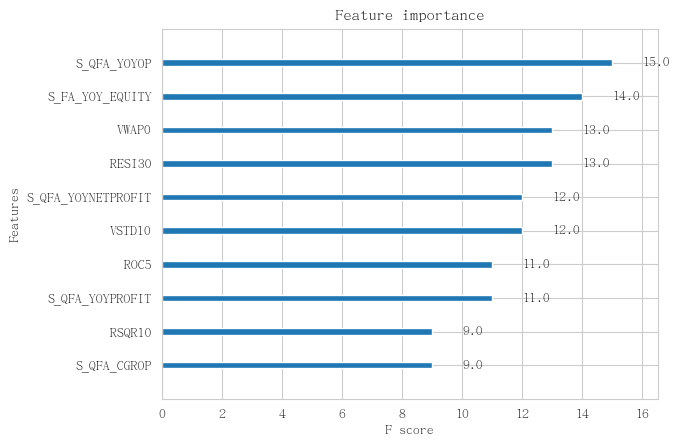

In [189]:
from xgboost import  plot_importance
plot_importance(xgb_model,max_num_features=10)

In [200]:
importance=xgb_model.get_booster().get_score(importance_type='weight')
sorted_importance=sorted(importance.items(),key=lambda x:x[1],reverse=True)
for feat,score in sorted_importance[100:]:
    print(f"{feat}:{score:.4f}")

TOT_LIAB:2.0000
STD20:2.0000
KLOW2:2.0000
AMORT_INTANG_ASSETS:2.0000
S_FA_GRPS:2.0000
S_FA_EPS_DILUTED_x:2.0000
S_FA_NONOPERATEPROFITTOEBT:2.0000
CNTP5:2.0000
IMAX30:2.0000
BETA30:2.0000
CNTP20:2.0000
QTLU30:2.0000
S_QFA_OPERATEINCOME:2.0000
S_FA_FCFEPS:2.0000
S_FA_EXINTERESTDEBT_NONCURRENT:2.0000
SUMD60:2.0000
BETA5:2.0000
MAX20:2.0000
STD5:2.0000
S_QFA_INVESTINCOME:2.0000
S_QFA_FINAEXPENSETOGR:2.0000
KSFT2:2.0000
S_FA_OPTOLIQDEBT:2.0000
TOT_CUR_ASSETS:2.0000
ROC20:2.0000
CNTD60:2.0000
BETA60:2.0000
S_FA_ROE_YEARLY:2.0000
RSQR5:2.0000
S_FA_TOT_FATURN:2.0000
S_FA_YOYOCFPS:2.0000
IMAX60:2.0000
S_QFA_CGRPROFIT:2.0000
RSQR60:2.0000
S_FA_YOYNETPROFIT_DEDUCTED:2.0000
IMXD20:2.0000
S_FA_DUPONT_ASSETSTOEQUITY:2.0000
SUMN10:1.0000
STM_BS_TOT:1.0000
S_QFA_ROE:1.0000
S_FA_FCFFPS:1.0000
IMIN5:1.0000
VSUMN5:1.0000
VSUMP60:1.0000
S_FA_YOYNETPROFIT:1.0000
IMXD60:1.0000
TOT_NON_CUR_LIAB:1.0000
TOT_OPER_COST2:1.0000
S_FA_TURNDAYS:1.0000
TOT_CUR_LIAB:1.0000
S_FA_TANGIBLEASSETSTOASSETS:1.0000
PREPAY:1.0

In [ ]:
y_pred

In [ ]:
y_train_rus

In [ ]:
y_pred

In [ ]:
#模型的预测结果整合，便于后续分析与回测，不需要回测就不需要运行该代码块
y_code_pn=y_code_pn[3620:].reset_index(drop=True)
y_pred_df=pd.DataFrame(y_pred,columns=['pred_label'])
pred_df = y_code_pn.join(y_pred_df)
pred_df.to_csv('high_dividend_test.csv',index=False)

In [ ]:
#默认阈值一般为0.5
y_pred_recall=y_pred[0:]>0.5
cnf_matrix=confusion_matrix(y_test,y_pred_recall)
class_names=[0,1]
plot_confusion_matrix(cnf_matrix,classes=class_names,fund_name='')

In [346]:
explainer=shap.Explainer(xgb_model)
shape_value=explainer.shap_values(X)
shap_df=pd.DataFrame(shape_value,columns=X_train_rus.columns)

In [347]:
# #输出每个特征的SHAP值（绝对值）
features=[]
shap_values_means=[]
for i,feature in enumerate(X_train_rus.columns):
    shap_values_mean=np.abs(shap_df.values[:,i]).mean()
    features.append(feature)
    shap_values_means.append(shap_values_mean)
tt=pd.DataFrame(features,columns=['features'])
tt['shap_values']=shap_values_means
tt_sort=tt.sort_values(by='shap_values',ascending=False)

In [348]:
tt_sort

,features,shap_values
284,S_QFA_YOYNETPROFIT,0.093562
120,RESI10,0.067212
140,RESI30,0.066707
146,S_QFA_YOYPROFIT,0.058368
93,S_QFA_DEDUCTEDPROFIT,0.057640
...,...,...
223,S_FA_GCTOGR,0.000000
224,S_FA_QUICK,0.000000
226,LESS_FIN_EXP,0.000000
59,S_STMNOTE_FINEXP,0.000000


In [350]:
tt_sort[tt_sort['shap_values']==0]['features'].tolist()

['DECR_OPER_PAYABLE',
 'NET_CASH_FLOWS_INV_ACT',
 'S_FA_ROA',
 'S_FA_ADMINEXPENSETOGR',
 'VSUMP5',
 'S_FA_ORPS',
 'S_FA_NCATOASSETS',
 'S_FA_CATURN',
 'QTLD30',
 'CNTN5',
 'S_STM_BS',
 'S_FA_EXTRAORDINARY',
 'BETA10',
 'OTH_RCV_TOT',
 'CNTD5',
 'IMAX5',
 'S_FA_ROIC',
 'ROC10',
 'NET_PROFIT_EXCL_MIN_INT_INC',
 'FIX_ASSETS',
 'RANK5',
 'IMXD20',
 'S_FA_PREFINEXPENSE_OPPROFIT',
 'TOT_LIAB',
 'S_FA_DUPONT_ASSETSTOEQUITY',
 'S_QFA_ROA',
 'S_FA_NETPROFITMARGIN',
 'S_FA_CASHRATIO',
 'S_FA_YOYBPS',
 'IMAX60',
 'CORR30',
 'S_FA_ROE_AVG',
 'S_QFA_NETPROFITMARGIN',
 'MA60',
 'S_FA_EPS_BASIC_x',
 'LESS_BEG_BAL_CASH',
 'S_FA_EQUITYTOTOTALCAPITAL',
 'QTLU10',
 'WAA_ROE',
 'S_FA_EQUITYTODEBT',
 'LESS_GERL_ADMIN_EXP',
 'S_QFA_ROE',
 'STM_BS_TOT',
 'CNTP30',
 'S_FA_OCFPS',
 'TOT_COMPREH_INC',
 'PLUS_NON_OPER_REV',
 'MA10',
 'VSUMP60',
 'OPER_PROFIT',
 'S_FA_OCFTOSHORTDEBT',
 'S_QFA_GCTOGR',
 'CNTN10',
 'S_FA_DEBTTOEQUITY',
 'TAXES_SURCHARGES_PAYABLE',
 'SUMN60',
 'CAP_RSRV',
 'S_FA_OPTOEBT',
 'VSUMD60'

In [ ]:
#摘要图，横轴：shap值，正的（正面影响）；纵轴：特征对模型预测贡献的平均绝对值排序；每个点代表一个样本，点的颜色表示该特征的值（红色表示特征值较高，蓝色表示特征值较低）
#正SHAP值表示该特征提高了对预测结果倾向于1的贡献
shape_value=explainer.shap_values(X)
shap.summary_plot(shape_value,X,max_display=15)

### 把第一步中标签为0，预测标签为1的数据也加入训练（未完成）

In [ ]:
df=positive_df[positive_df['pred_label']==1]

In [ ]:
# 按照DATETIME列进行分组，并将CODE合并成列表，同时去重
df_grouped = df.groupby('DATETIME')['CODE'].apply(lambda x: list(set(x))).reset_index()

# 更改列名以符合要求
df_grouped.columns = ['Date', 'Stock_list']

In [ ]:
df_grouped

In [ ]:
len(df_grouped['Stock_list'][0])

In [ ]:
##后续使用df_grouped进行训练，代码类似

### 测试集当训练集再训练一个模型

In [ ]:
rus=RandomUnderSampler(sampling_strategy=1) #比例1：10
X_train_rus1,y_train_rus1=rus.fit_resample(X_test,y_test)
# X_train_rus1,y_train_rus1=X_test,y_test
X_test1,y_test1=X_test,y_test

In [ ]:
#统计当前类别占比情况
print("Before undersampling:",Counter(y_test))

In [ ]:
#XGBoost模型定义与训练
xgb_model=XGBClassifier()
xgb_model.fit(X_train_rus1,y_train_rus1)

In [ ]:
#XGBoost模型评估,Recall:实际为正类样本中被正确预测为正类的比例，Precision：预测为正类的样本中实际为正类的比例，F1：2×（（recall×precision）/（recall+precision））
y_pred1=xgb_model.predict(X_test1)
metric_score(test_y=y_test1,pre_y=y_pred1)

In [ ]:
explainer=shap.Explainer(xgb_model)
shape_value=explainer.shap_values(X)
shap_df=pd.DataFrame(shape_value,columns=X_train_rus.columns)

In [ ]:
# #输出每个特征的SHAP值（绝对值）
features=[]
shap_values_means=[]
for i,feature in enumerate(X_train_rus.columns):
    shap_values_mean=np.abs(shap_df.values[:,i]).mean()
    features.append(feature)
    shap_values_means.append(shap_values_mean)
tt=pd.DataFrame(features,columns=['features'])
tt['shap_values']=shap_values_means
tt_sort=tt.sort_values(by='shap_values',ascending=False)
tt_sort